# PHYS 309 Assignment 1

### Getting started

<ul>
    <li><strong>I strongly recommend that you install <tt>python</tt> and <tt>Jupyter notebook</tt> on your own computer.</strong> The <a href="https://www.anaconda.com/products/distribution">Anaconda <tt>python</tt> distribution</a> is free for individual use. You may also use <a href="https://colab.research.google.com/">Google colab</a>, but it has session time limitations.</li>
    <li>Download this notebook to your own computer, open with <tt>Jupyter</tt> notebook or lab, and complete the missing code. See the <a href="https://docs.jupyter.org/en/latest/start/index.html"><tt>Jupyter</tt> documentation</a> for help.</li>
</ul>

<strong>For full credit, you must do the following:</strong>
<ul>
    <li>Instead of putting in the values of physical constants such as $c$ and $\epsilon_0$ by hand, use SI values pre-programmed into [scipy.constants](https://docs.scipy.org/doc/scipy/reference/constants.html). For example, $\mu_0$ is <tt>constants.mu_0</tt>.</li>
    <li>Instead of native <tt>python</tt> lists, use <a href="https://numpy.org/doc/stable/user/absolute_beginners.html">NumPy</a> arrays. Change<br />
    &nbsp; &nbsp; <tt>r = []<br />
    &nbsp;  for i in range(100):<br />
    &nbsp; &nbsp; &nbsp; r.append(i)<br /></tt>
    to<br />
    &nbsp; &nbsp;  <tt>r = <a href="https://numpy.org/doc/stable/reference/generated/numpy.arange.html">np.arange(100)</a></tt>
    </li>   
</ul>

### Set up <tt>python</tt> environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import types

# Contains physical constants defined in SI units (default) as well as other systems
from scipy import constants

# Image display
#  (the`ere are multiple ways to do this; the line below facilitates one of them)
from PIL import Image

# Make easily readable plots with large axis labels
plt.rcParams.update({"font.size":16, "axes.labelsize":16, "font.family":"sans-serif", 
                     "font.sans-serif":"Arial"})

### Questions


Recall that the speed of light in vacuum is 
\begin{equation}
c = \frac{1}{\sqrt{\epsilon_0 \mu_0}}, \; \; \; \; \; (1)
\end{equation}
where $\epsilon_0 = 8.85 \times 10^{-12}$ F/m (Farads per meter)$^{*}$ is the electric permittivity of free space and $\mu_0 = 1.26 \times 10^{-6}$ N/A$^2$ (Newtons per Ampere$^2$)$^{**}$ is the magnetic permeability of free space. The electric field created by a point charge $q$ is
\begin{equation}
E = \frac{1}{4 \pi \epsilon_0} \frac{q}{r^2}. \; \; \; \; (2)
\end{equation}
Suppose a charged particle is moving at some fraction of the speed of light in vacuum ($v_q = f c; \; 0 < f < 1$) as seen in reference frame $S$. Reference frame $S^{\prime}$ is co-moving with the point charge, so that $\frac{dx^{\prime}}{dt^{\prime}} = v^{\prime}_q = 0$ in frame $S^{\prime}$. To make the math easier, put $q$ at the origin of $S^{\prime}$.

To understand Einstein's motivation for developing the special theory of relativity, make the <strong>incorrect, erroneous, and wrong</strong> assumption that the Galilean velocity transformation holds true for all values of $f$:
\begin{equation}
\frac{dx^{\prime}}{dt^{\prime}} = \frac{dx}{dt} - v_q \; \; \; (3)
\end{equation}

<ol>
    <li>Assume the charged particle is an electron. Using Equation 2, calculate and plot the electric field as a function of distance $r^{\prime}$ from $q$ in frame $S^{\prime}$. Choose an x-axis range that makes sense to you and label both axes with correct units.</li>
</ol>

Text(0, 0.5, 'Electric field (N/C)')

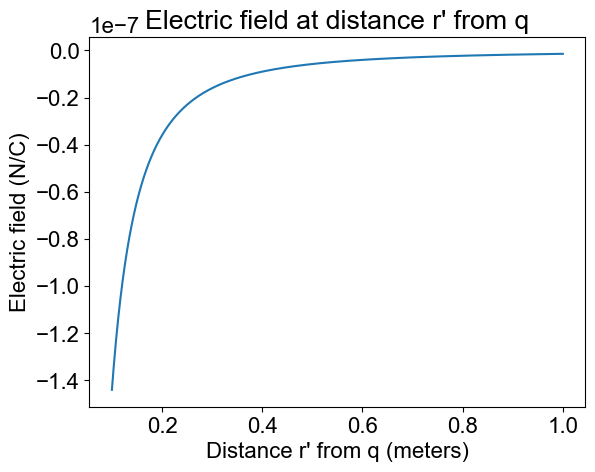

In [2]:
def graph(ax: Axes, formula: types.FunctionType, x_start, x_end, n_points=1000, label="", color="") -> None:
    x = np.linspace(x_start, x_end, num=n_points)
    y = formula(x) 
    if color:
        ax.plot(x, y, label=label, color=color)
    else:
        ax.plot(x, y, label=label)

k = 1 / (4 * constants.pi * constants.epsilon_0)
q = -constants.elementary_charge
def E_field_from_point_charge(r_prime: float) -> float:
    return k * q / (r_prime ** 2)

fig, ax = plt.subplots()
graph(ax, E_field_from_point_charge, 0.1, 1)
ax.set_title("Electric field at distance r' from q")
ax.set_xlabel("Distance r' from q (meters)")
ax.set_ylabel("Electric field (N/C)")

<ol start=2>
    <li>The Galilean velocity transformation suggests that objects can "catch up" with light, so that light in a vacuum appears to be going slower than the value of $c$ from Equation (1). Make a plot of $c^{\prime}$, the <strong>incorrect</strong> speed of light in frame $S^{\prime}$ according to the Galilean transformation, as a function of $f$. Put units on the axes where appropriate.</li>
</ol>

Text(0, 0.5, 'Incorrect speed of light (m/s)')

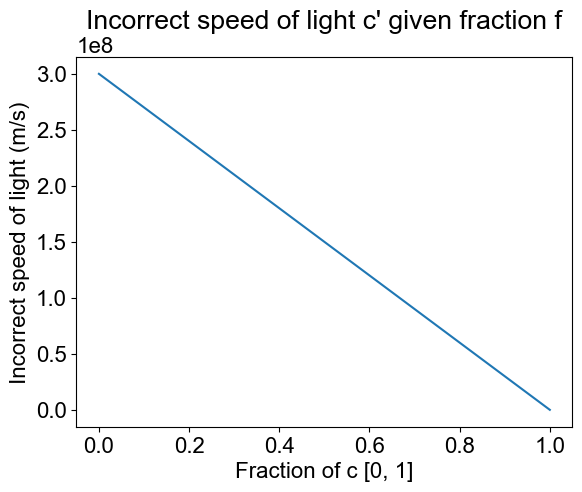

In [3]:
def c_prime(f: float) -> float:
    return constants.c * (1 - f)

fig, ax = plt.subplots()
graph(ax, c_prime, 0, 1)
ax.set_title("Incorrect speed of light c' given fraction f")
ax.set_xlabel("Fraction of c [0, 1]")
ax.set_ylabel("Incorrect speed of light (m/s)")

<ol start=3>
    <li>In frame $S^{\prime}$, something has to give: either Equation (1) is no longer true, or the values of $\epsilon_0$ and/or $\mu_0$ have to change. Suppose Equation (1) is still true and $\mu_0 = \mu_0^{\prime}$. Make a plot with two vertically stacked subplots. The top subplot should show $\epsilon_0^{\prime}$ as a function of $f$, while the bottom plot should show the electric field $E^{\prime} = \frac{1}{4 \pi \epsilon_0^{\prime}} \frac{q}{{r^{\prime}}^2}$ at $r^{\prime} = 1 \mu \mathrm{m} = 10^{-6}$ m as a function of $f$. Put units on the axes where appropriate.</li>
</ol>

Text(0, 0.5, 'Electric field (N/C)')

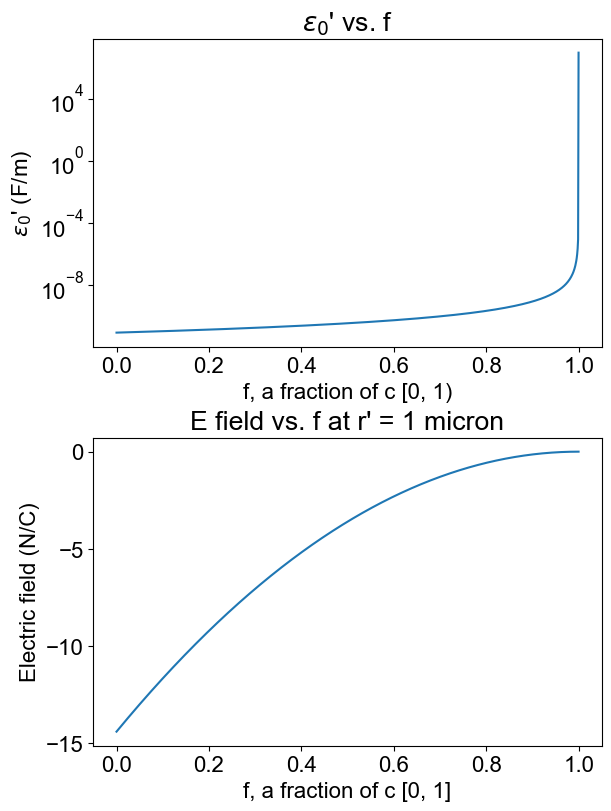

In [4]:
r_prime = 10e-6

def e_0_prime(f: float) -> float:
    return 1 / (constants.mu_0 ** 0.5 * constants.c * (1 - f)) ** 2

def E_prime(f: float) -> float:
    return ((constants.mu_0 ** 0.5 * constants.c * (1 - f)) ** 2) / (4 * constants.pi) * q / (r_prime ** 2)

fig, (ax1, ax2) = plt.subplots(2, layout="constrained")
fig.set_size_inches(6, 8)
graph(ax1, e_0_prime, 0, 1 - 1e-9)
ax1.set_yscale("log")
ax1.set_title(r"$\epsilon_0$' vs. f")
ax1.set_xlabel("f, a fraction of c [0, 1)")
ax1.set_ylabel(r"$\epsilon_0$' (F/m)")

graph(ax2, E_prime, 0, 1)
ax2.set_title("E field vs. f at r' = 1 micron")
ax2.set_xlabel("f, a fraction of c [0, 1]")
ax2.set_ylabel("Electric field (N/C)")

<ol start=4>
    <li>Now assume $f = 0.5$. In the same plot window, plot $E^{\prime}(r^{\prime})$ given by Equation 2 (same curve as in Problem 1) <em>and</em> $E^{\prime}(r^{\prime})$ calculated as in Problem 3, where $\epsilon_0^{\prime}$ is a function of $f$. Do you notice a problem?</li>
</ol>

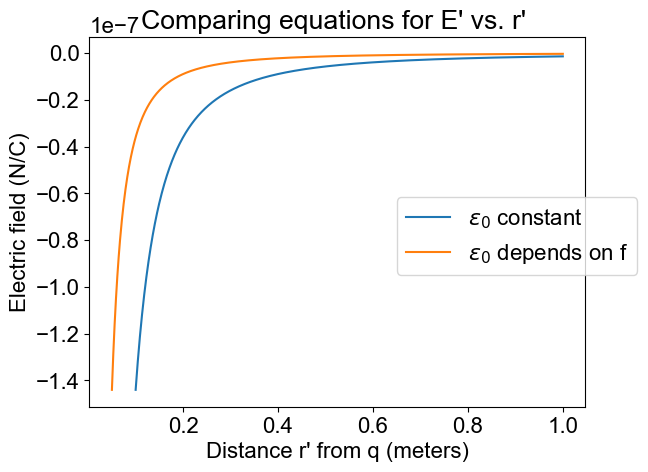

In [5]:
def E_field_at_r_prime_f(r_prime: float) -> float:
    f = 0.5
    return ((constants.mu_0 ** 0.5 * constants.c * (1 - f)) ** 2) / (4 * constants.pi) * q / (r_prime ** 2)

fig, ax = plt.subplots()
graph(ax, E_field_from_point_charge, 0.1, 1, label=r"$\epsilon_0$ constant")
graph(ax, E_field_at_r_prime_f, 0.05, 1, label=r"$\epsilon_0$ depends on f")
ax.set_title("Comparing equations for E' vs. r' ")
ax.set_xlabel("Distance r' from q (meters)")
ax.set_ylabel("Electric field (N/C)")
fig.legend(loc="center right")

By this model, the electric field E' at a given distance r' from an point charge changes varies based on the point charge's relative velocity (expressed as fraction f of c). In this model, this variance is a consequence of varying the constant e_0. According to this model, the laws of physics behave inconsistently for inertial frames at different relative velocities.

<ol start=5>
    <li>To resolve the issues revealed by the plot from Problem 4, you may suggest setting $\epsilon_0^{\prime} = \epsilon_0$ and allowing $\mu_0^{\prime}$ to vary with $f$. Let's explore that solution. To accompany the point charge in problems 1-4, add a current loop that's also at rest in frame $S^{\prime}$. Recall that the magnitude of the magnetic field strength at the center of the loop in frame $S$ is $B = \frac{\mu_0 I}{2R}$, where $I$ is the current and $R$ is the radius of the loop. Suppose $I = 1$ A and $R = 1$ m. Assume $E^{\prime} = E$, $B^{\prime} = B$, and $c^{\prime}$ depends on $f$ as in problem 2. Plot $\mu_0$ as a function of $f$.</li>
</ol>

Text(0, 0.5, "$\\mu_0$' (N/A^2)")

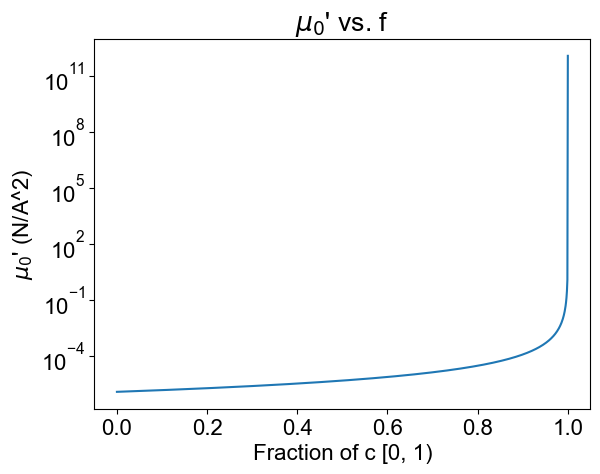

In [6]:
def mu_0_prime(f: float) -> float:
    return 1 / (constants.epsilon_0 ** 0.5 * constants.c * (1 - f)) ** 2

fig, ax = plt.subplots()
graph(ax, mu_0_prime, 0, 1 - 1e-9)
ax.set_yscale("log")
ax.set_title(r"$\mu_0$' vs. f")
ax.set_xlabel("Fraction of c [0, 1)")
ax.set_ylabel(r"$\mu_0$' (N/A^2)")

<ol start=6>
<li>If we calculate $c^{\prime}$ using the Galilean transformation in Equation 3, is there any value of $f$ for which $E^{\prime} = E$ <strong>and</strong> $B^{\prime} = B$? Make a graph to illustrate your answer.</li>
</ol>

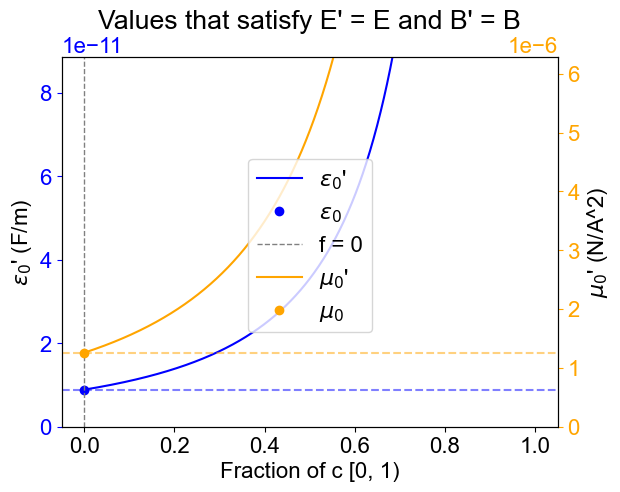

In [7]:
fig, ax1 = plt.subplots()
graph(ax1, e_0_prime, 0, 1 - 1e-9, label=r"$\epsilon_0$'", color="blue")
ax1.plot(0, constants.epsilon_0, 'o', label=r"$\epsilon_0$", color="blue")
ax1.tick_params(axis="y", colors="blue")
ax1.set_xlabel("Fraction of c [0, 1)")
ax1.set_ylabel(r"$\epsilon_0$' (F/m)")
ax1.axhline(y=constants.epsilon_0, color='blue', linestyle='--', alpha=0.5)

ax1.set_title("Values that satisfy E' = E and B' = B")
ax2 = ax1.twinx()

graph(ax2, mu_0_prime, 0, 1 - 1e-9, label=r"$\mu_0$'", color="orange")
ax2.plot(0, constants.mu_0, 'o', label=r"$\mu_0$", color="orange")
ax2.tick_params(axis="y", colors="orange")
ax2.set_xlabel("Fraction of c [0, 1)")
ax2.set_ylabel(r"$\mu_0$' (N/A^2)")
ax2.axhline(y=constants.mu_0, color='orange', linestyle='--', alpha=0.5)

ax1.axvline(x=0, color='gray', linestyle='--', linewidth=1, label="f = 0")
ax1.set_ylim(0, constants.epsilon_0 * 10)  
ax2.set_ylim(0, constants.mu_0 * 5)
fig.legend(loc="center")

f = 0 is the only value of f that satisfies the conditions for E' = E and B' = B. See the corresponding PDF for my work.

Conceptual questions about the conflict between the Galilean velocity transformation and E&M are in the written homework assignment.

$^{*}$Farad = Coulomb/Volt: Farad is the unit of capacitance, which measures the amount of charge necessary to increase the electric potential of a system by 1 Volt. Farads/meter measure how much capacitance you get per meter of free space between yourself and a charged particle.

$^{**}$Newtons/Ampere$^2$ = Newtons/(Coulombs/second)$^2$. $\mu_0$ measures how effective inductance is at creating magnetic force in free space.

<strong>Getting set up for the class research project:</strong>
<ol start=7>
    <li>Go to the download page for <a href="https://www.cosmos.esa.int/web/herschel/hipe-download">HIPE</a> (Herschel Interactive Processing Environment)</li>
    <li>Choose and download the appropriate version of HIPE for your computer</li>
    <li>Open HIPE on your computer and take a screenshot of the landing page. Use the code cell below to display your screenshot.</li>
</ol>

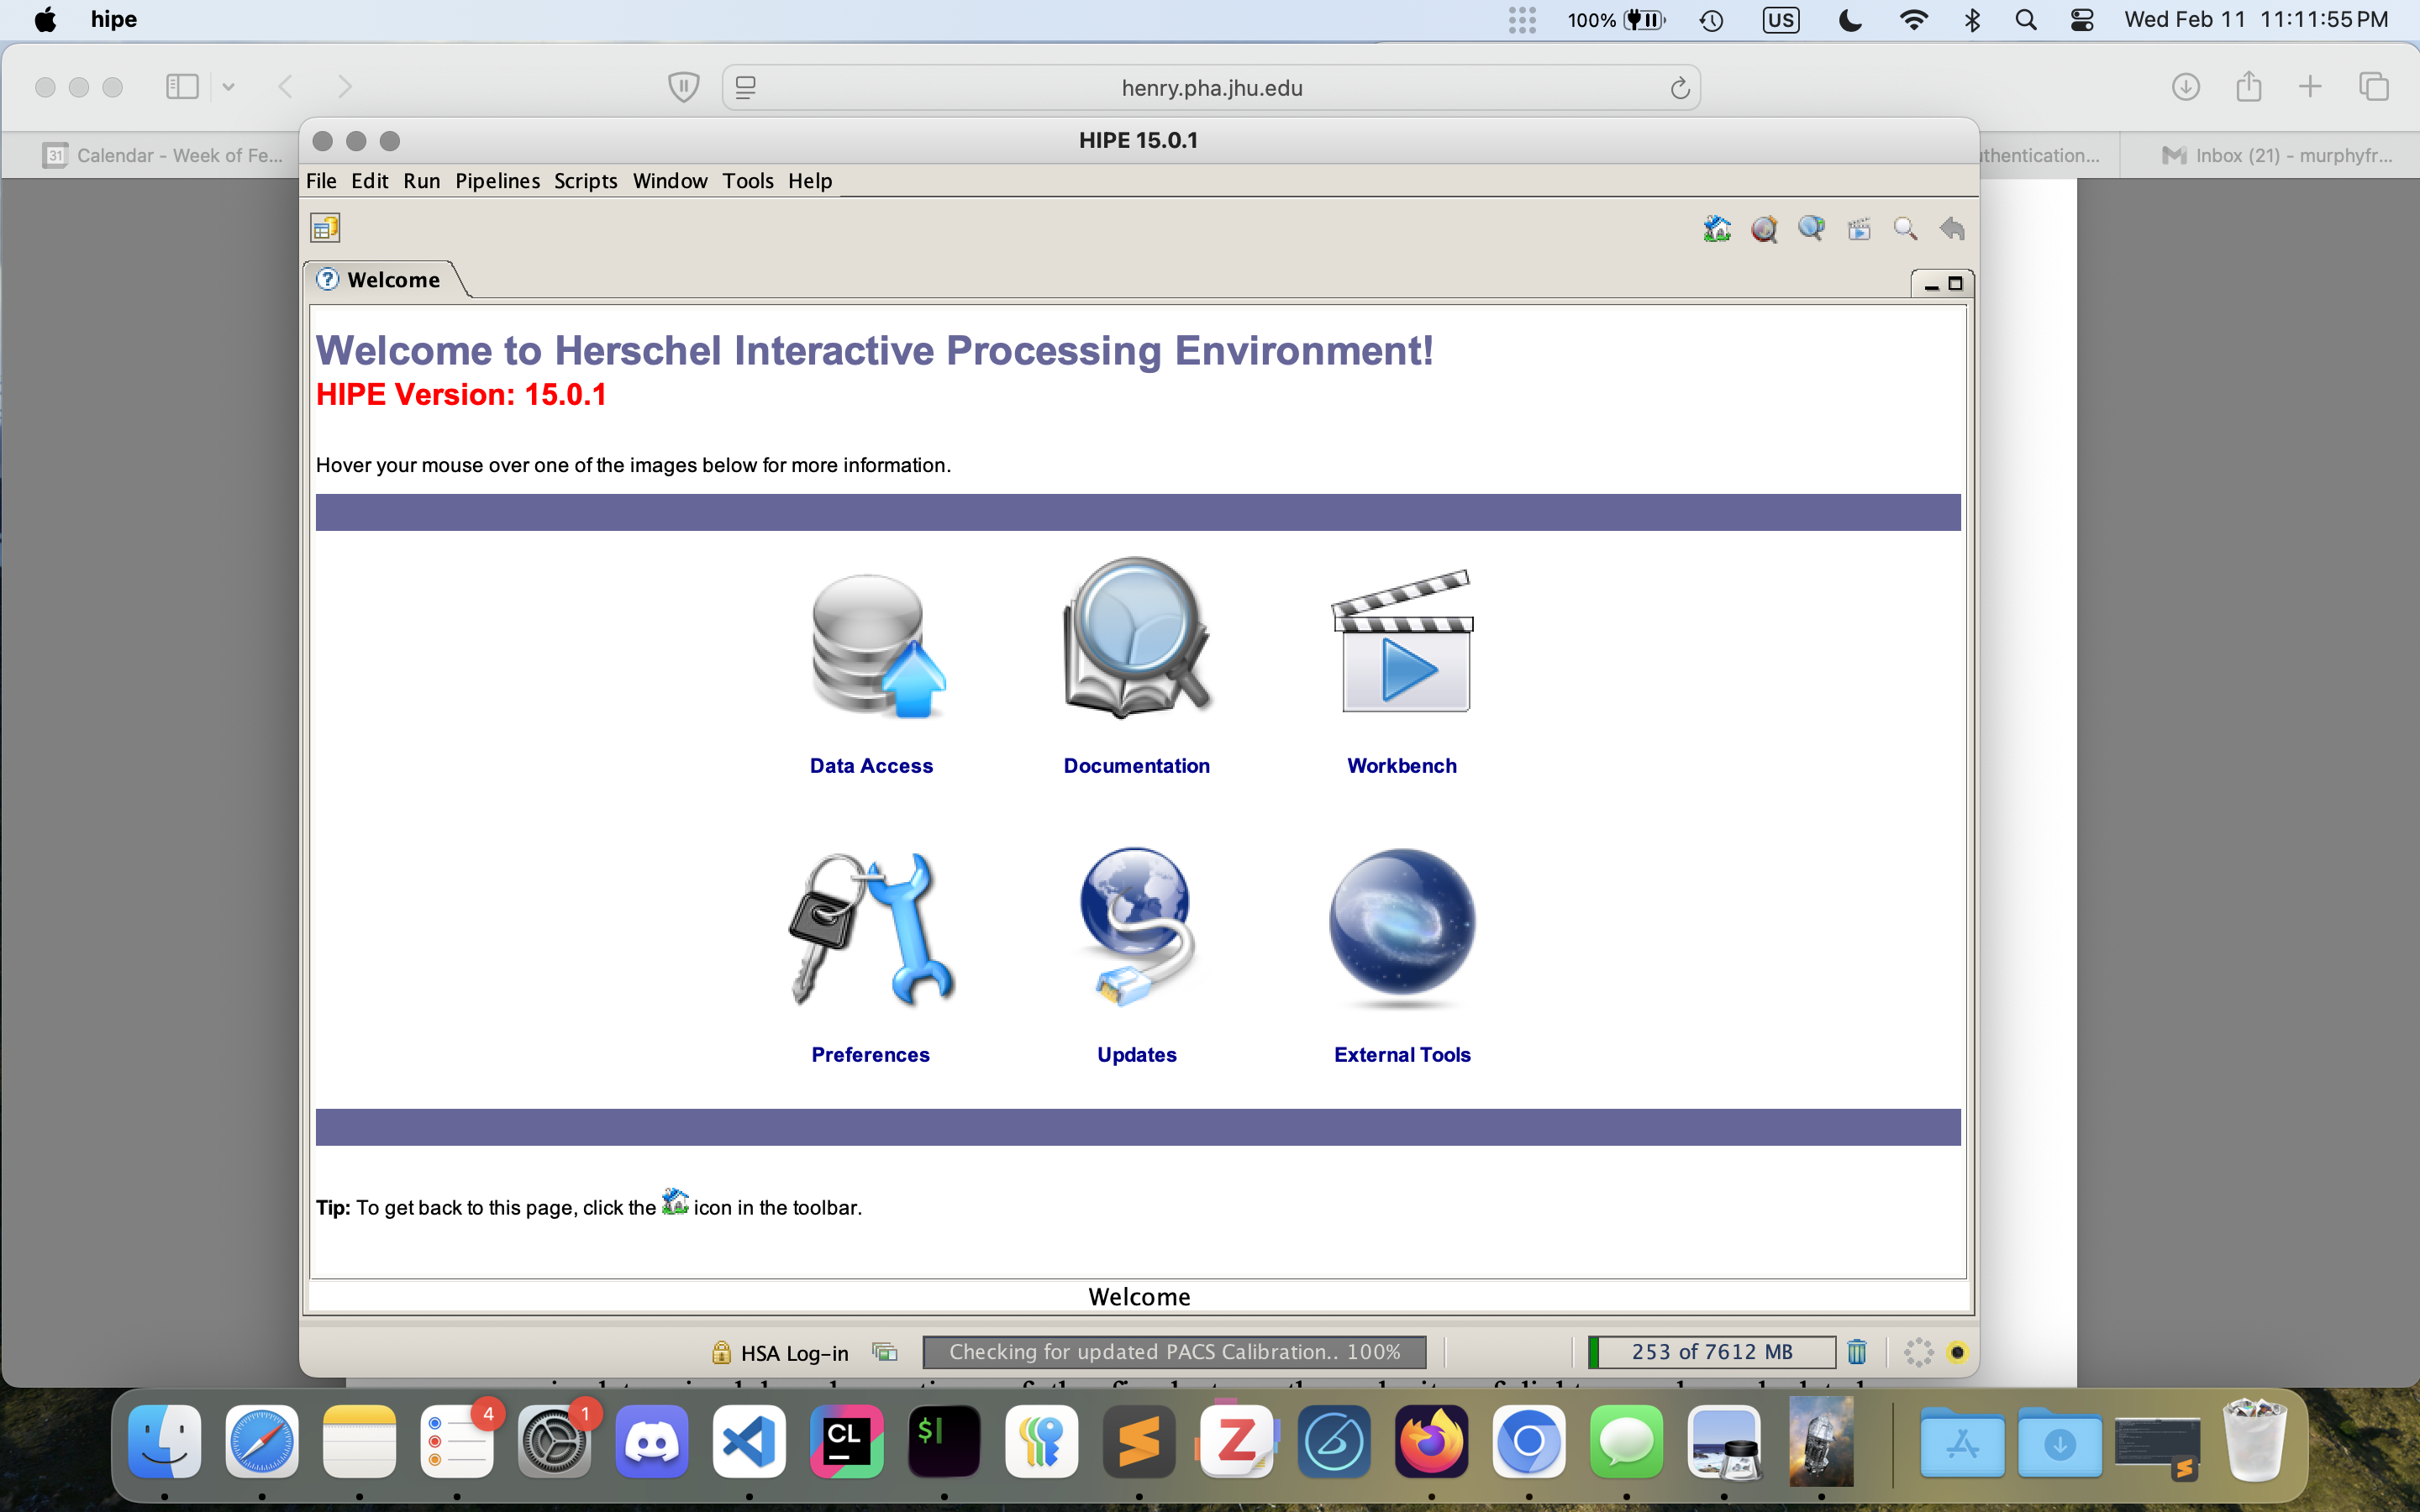

In [9]:
img = Image.open('./HIPE.png')
img